# recount2 — C2CP Pathway Coverage vs Sample Size

**Environment:** `clamp-analyses`

Plots the C2CP pathway coverage and K (number of components) results produced by `01_recount2_coverage.ipynb`.

Coverage = proportion of input C2CP pathways significantly associated with an LV (FDR < 0.05),
following the `GetPathwayCoverage` approach from the multi-plier paper (Taroni 2018).

Input: `output/recount2/c2cp_subsample_{N}_seed_{idx}/CLAMPfull_C2CP.rds`

## Libraries

In [8]:
library(dplyr)
library(ggplot2)
library(here)

source(here("config.R"))

## Configuration

In [9]:
FDR_CUTOFF   <- 0.05
output_dir   <- file.path(config$GENERAL$OUTPUT_DIR, "recount2")
sample_sizes <- c(500, 1000, 2000, 4000, 8000, 16000, 32000)
n_seeds      <- 3

## Coverage function

In [10]:
# Adapted from GetPathwayCoverage (Taroni 2018 / multi-plier)
GetPathwayCoverage <- function(clamp.result, fdr.cutoff = 0.05) {
    summary.df     <- clamp.result$summary
    input.pathways <- colnames(clamp.result$C)
    num.lvs        <- ncol(clamp.result$U)

    sig.pathways <- unique(summary.df$pathway[which(summary.df$FDR < fdr.cutoff)])
    sig.lvs      <- unique(summary.df$LV[which(summary.df$FDR < fdr.cutoff)])

    list(
        pathway           = length(sig.pathways) / length(input.pathways),
        lv                = length(sig.lvs) / num.lvs,
        sig.pathway.by.lv = length(sig.pathways) / num.lvs
    )
}

## Collect results per run

In [11]:
rows <- list()

for (n_target in sample_sizes) {
    for (seed_idx in seq_len(n_seeds)) {
        run_dir  <- file.path(output_dir,
                              paste0("c2cp_subsample_", n_target, "_seed_", seed_idx))
        rds_path <- file.path(run_dir, "CLAMPfull_C2CP.rds")
        k_path   <- file.path(run_dir, "CLAMP_K.rds")

        if (!file.exists(rds_path)) {
            message("Not found — skipping: c2cp_subsample_",
                    n_target, "_seed_", seed_idx)
            next
        }

        model   <- readRDS(rds_path)
        clamp_k <- if (file.exists(k_path)) readRDS(k_path) else NA_integer_
        cov     <- GetPathwayCoverage(model, fdr.cutoff = FDR_CUTOFF)

        rows[[length(rows) + 1]] <- data.frame(
            sample_size      = n_target,
            n_samples        = ncol(model$B),
            seed             = seed_idx,
            pathway_coverage = cov$pathway,
            lv_coverage      = cov$lv,
            clamp_k          = clamp_k
        )
        message(sprintf("n=%6d  seed=%d  pathway_cov=%.2f%%  K=%d",
                        n_target, seed_idx,
                        cov$pathway * 100, clamp_k))
    }
}

results_df <- dplyr::bind_rows(rows) %>%
    dplyr::mutate(sample_size = factor(sample_size,
                                       levels = sort(unique(sample_size))))
print(results_df)

n=   500  seed=1  pathway_cov=3.56%  K=20

n=   500  seed=2  pathway_cov=6.82%  K=174

n=   500  seed=3  pathway_cov=6.59%  K=152

n=  1000  seed=1  pathway_cov=7.31%  K=294

n=  1000  seed=2  pathway_cov=8.62%  K=148

n=  1000  seed=3  pathway_cov=5.28%  K=82

n=  2000  seed=1  pathway_cov=10.00%  K=368

n=  2000  seed=2  pathway_cov=9.82%  K=434

n=  2000  seed=3  pathway_cov=11.46%  K=410

n=  4000  seed=1  pathway_cov=12.06%  K=474

n=  4000  seed=2  pathway_cov=10.57%  K=466

n=  4000  seed=3  pathway_cov=5.10%  K=568

n=  8000  seed=1  pathway_cov=1.69%  K=1346

n=  8000  seed=2  pathway_cov=5.06%  K=642

n=  8000  seed=3  pathway_cov=5.77%  K=582

n= 16000  seed=1  pathway_cov=5.77%  K=700

Not found — skipping: c2cp_subsample_16000_seed_2

Not found — skipping: c2cp_subsample_16000_seed_3

Not found — skipping: c2cp_subsample_32000_seed_1

Not found — skipping: c2cp_subsample_32000_seed_2

Not found — skipping: c2cp_subsample_32000_seed_3



   sample_size n_samples seed pathway_coverage lv_coverage clamp_k
1          500       500    1       0.03559386  0.95000000      20
2          500       500    2       0.06819033  0.55747126     174
3          500       500    3       0.06594230  0.62500000     152
4         1000      1000    1       0.07306107  0.42517007     294
5         1000      1000    2       0.08617460  0.70945946     148
6         1000      1000    3       0.05282877  0.74390244      82
7         2000      2000    1       0.10003747  0.54076087     368
8         2000      2000    2       0.09816411  0.46543779     434
9         2000      2000    3       0.11464968  0.53658537     410
10        4000      4000    1       0.12064444  0.48101266     474
11        4000      4000    2       0.10565755  0.42489270     466
12        4000      4000    3       0.05095541  0.19014085     568
13        8000      8000    1       0.01686025  0.02451709    1346
14        8000      8000    2       0.05058074  0.16355140    

## Pathway coverage

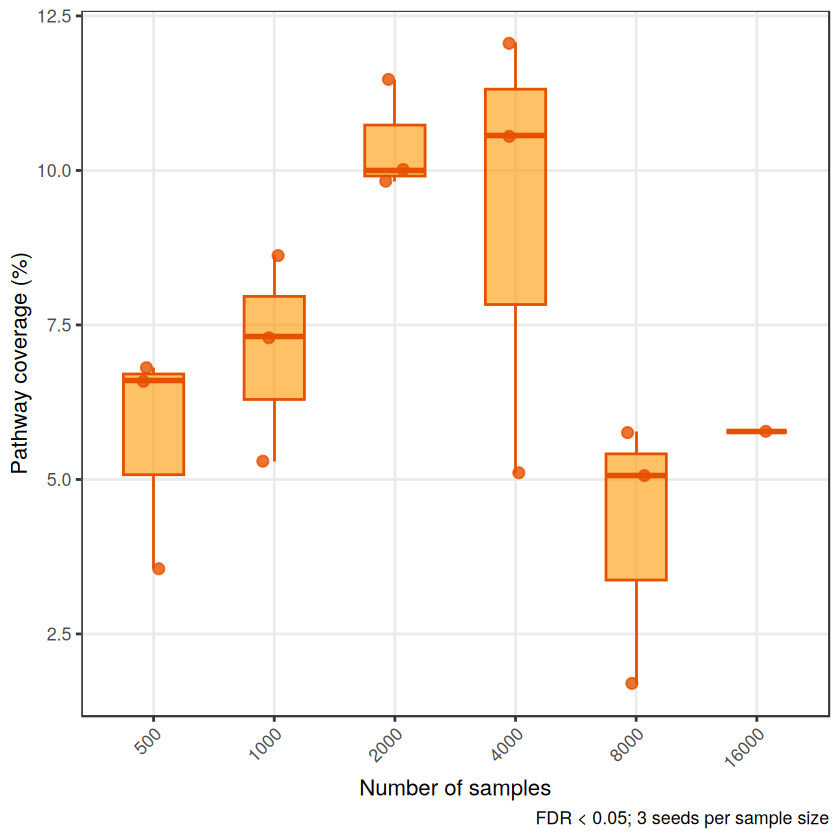

In [12]:
p_cov <- ggplot(results_df,
                aes(x = sample_size, y = pathway_coverage * 100)) +
    geom_boxplot(fill = "#FF9800", color = "#E65100",
                 alpha = 0.6, outlier.shape = NA, width = 0.5) +
    geom_jitter(color = "#E65100", width = 0.1, size = 2.5, alpha = 0.8) +
    labs(
        x       = "Number of samples",
        y       = "Pathway coverage (%)",
        caption = paste0("FDR < ", FDR_CUTOFF, "; 3 seeds per sample size")
    ) +
    theme_bw(base_size = 13) +
    theme(
        axis.text.x      = element_text(angle = 45, hjust = 1),
        panel.grid.minor = element_blank()
    )

print(p_cov)

## K (number of components)

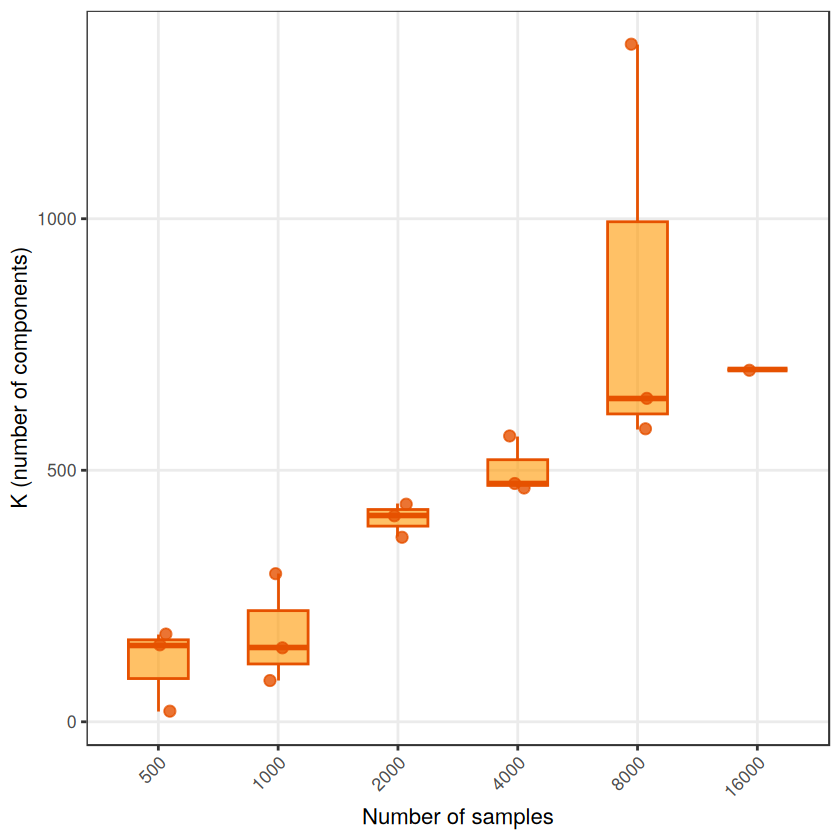

In [13]:
p_k <- ggplot(results_df,
              aes(x = sample_size, y = clamp_k)) +
    geom_boxplot(fill = "#FF9800", color = "#E65100",
                 alpha = 0.6, outlier.shape = NA, width = 0.5) +
    geom_jitter(color = "#E65100", width = 0.1, size = 2.5, alpha = 0.8) +
    labs(
        x = "Number of samples",
        y = "K (number of components)"
    ) +
    theme_bw(base_size = 13) +
    theme(
        axis.text.x      = element_text(angle = 45, hjust = 1),
        panel.grid.minor = element_blank()
    )

print(p_k)

## Summary table

In [14]:
results_df %>%
    dplyr::group_by(sample_size) %>%
    dplyr::summarise(
        median_cov = round(median(pathway_coverage) * 100, 2),
        min_cov    = round(min(pathway_coverage) * 100, 2),
        max_cov    = round(max(pathway_coverage) * 100, 2),
        median_k   = median(clamp_k, na.rm = TRUE),
        n          = dplyr::n(),
        .groups    = "drop"
    ) %>%
    dplyr::arrange(sample_size)

sample_size,median_cov,min_cov,max_cov,median_k,n
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
500,6.59,3.56,6.82,152,3
1000,7.31,5.28,8.62,148,3
2000,10.00,9.82,11.46,410,3
4000,10.57,5.10,12.06,474,3
8000,5.06,1.69,5.77,642,3
16000,5.77,5.77,5.77,700,1
